# Modelisation predictive -- JO 2028 (simplifiee)

---

## Objectif

Predire pour LA 2028 :
1. Nombre de medailles **Or** par couple (pays, sport)
2. Nombre de medailles **Argent** par couple (pays, sport)
3. Nombre de medailles **Bronze** par couple (pays, sport)

Puis **agreger au niveau pays** pour le classement final.

## Approche

- 3 modeles Ridge entraines independamment
- Features : lag_1, lag_2, rolling_3 (par couleur), is_host, log_population, Continent, Sport
- Split temporel : train 1968-2016, test 2024


## 1. Imports et chargement

In [1]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

PROCESSED_DIR = os.path.join('..', 'data', 'processed')
MODELS_DIR = os.path.join('..', 'models')
os.makedirs(MODELS_DIR, exist_ok=True)

df = pd.read_csv(os.path.join(PROCESSED_DIR, 'medals_per_country_sport.csv'))
print(f'Dataset charge : {df.shape}')
print(f'Annees : {df["Year"].min()} - {df["Year"].max()}')
print(f'Pays   : {df["NOC"].nunique()}')
print(f'Sports : {df["Sport"].nunique()}')

Dataset charge : (7454, 10)
Annees : 1896 - 2024
Pays   : 159
Sports : 85


## 2. Grille complete (NOC x Year x Sport)

Inclure les 0 pour que le modele apprenne aussi a predire les non-medailles.

In [2]:
top_sports = df.groupby('Sport')['Total'].sum().sort_values(ascending=False).head(30).index.tolist()
all_nocs = df['NOC'].unique()
years = sorted(df['Year'].unique())

print(f'Top 30 sports : {len(top_sports)}')
print(f'Pays          : {len(all_nocs)}')
print(f'Annees        : {len(years)}')

grid = pd.MultiIndex.from_product([all_nocs, years, top_sports],
                                    names=['NOC', 'Year', 'Sport']).to_frame(index=False)

df_full = grid.merge(df[['NOC', 'Year', 'Sport', 'Gold', 'Silver', 'Bronze', 'Total']],
                       on=['NOC', 'Year', 'Sport'], how='left').fillna(0)
df_full[['Gold','Silver','Bronze','Total']] = df_full[['Gold','Silver','Bronze','Total']].astype(int)

country_map = df[['NOC', 'Country', 'Continent']].drop_duplicates(subset=['NOC'])
df_full = df_full.merge(country_map, on='NOC', how='left')

pop_map = df[['NOC', 'Year', 'Population']].drop_duplicates(subset=['NOC','Year'])
df_full = df_full.merge(pop_map, on=['NOC', 'Year'], how='left')

print(f'Grille : {df_full.shape}')
print(f'Ratio zeros : {(df_full["Total"]==0).sum() / len(df_full) * 100:.1f} %')

Top 30 sports : 30
Pays          : 159
Annees        : 30
Grille : (143100, 10)
Ratio zeros : 95.6 %


## 3. Feature engineering

lag_1, lag_2, rolling_3 par couleur + is_host + log_population + Continent.

In [3]:
df_full = df_full.sort_values(['NOC', 'Sport', 'Year']).reset_index(drop=True)

for col in ['Gold', 'Silver', 'Bronze']:
    df_full[f'lag_1_{col}'] = df_full.groupby(['NOC', 'Sport'])[col].shift(1)
    df_full[f'lag_2_{col}'] = df_full.groupby(['NOC', 'Sport'])[col].shift(2)
    df_full[f'rolling_3_{col}'] = (df_full.groupby(['NOC', 'Sport'])[col]
                                    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean()))

host_per_year = {
    1960:'ITA', 1964:'JPN', 1968:'MEX', 1972:'GER', 1976:'CAN', 1980:'URS',
    1984:'USA', 1988:'KOR', 1992:'ESP', 1996:'USA', 2000:'AUS', 2004:'GRE',
    2008:'CHN', 2012:'GBR', 2016:'BRA', 2020:'JPN', 2024:'FRA', 2028:'USA',
}
df_full['is_host'] = df_full.apply(
    lambda row: 1 if host_per_year.get(int(row['Year'])) == row['NOC'] else 0, axis=1)

df_full['log_population'] = np.log1p(df_full['Population'].fillna(0))
median_log = df_full[df_full['log_population'] > 0]['log_population'].median()
df_full.loc[df_full['log_population'] == 0, 'log_population'] = median_log

for col in df_full.columns:
    if col.startswith(('lag_', 'rolling_')):
        df_full[col] = df_full[col].fillna(0)

df_full['Continent'] = df_full['Continent'].fillna('Unknown')
df_model = df_full[df_full['Year'] >= 1968].copy()
print(f'Dataset modele : {df_model.shape}')

Dataset modele : (71550, 21)


## 4. Split temporel

Train : 1968-2016 | Test : 2024 (Paris).

In [4]:
def prepare_X(df_part, target_color):
    features_num = [f'lag_1_{target_color}', f'lag_2_{target_color}', f'rolling_3_{target_color}',
                     'is_host', 'log_population']
    X_num = df_part[features_num].copy()
    X_cat = pd.get_dummies(df_part[['Continent', 'Sport']], drop_first=True)
    return pd.concat([X_num, X_cat], axis=1)

train = df_model[df_model['Year'].between(1968, 2016)].copy()
test = df_model[df_model['Year'] == 2024].copy()
print(f'Train : {train.shape[0]:,} lignes')
print(f'Test  : {test.shape[0]:,} lignes')

Train : 62,010 lignes
Test  : 4,770 lignes


## 5. Entrainement des 3 modeles (Or, Argent, Bronze)

GridSearchCV sur alpha pour chaque couleur.

In [5]:
models = {}
results_metrics = {}

for color in ['Gold', 'Silver', 'Bronze']:
    print(f'\n=== Modele {color} ===')
    X_tr = prepare_X(train, color)
    y_tr = train[color]
    X_te = prepare_X(test, color).reindex(columns=X_tr.columns, fill_value=0)
    y_te = test[color]

    pipe = Pipeline([('scaler', StandardScaler()), ('model', Ridge())])
    gs = GridSearchCV(pipe, {'model__alpha': [0.1, 1.0, 10.0, 100.0, 1000.0]},
                       cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
    gs.fit(X_tr, y_tr)

    preds = np.maximum(gs.predict(X_te), 0)
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    mae = mean_absolute_error(y_te, preds)
    r2 = r2_score(y_te, preds)

    print(f'  Best alpha : {gs.best_params_["model__alpha"]}')
    print(f'  RMSE = {rmse:.3f} | MAE = {mae:.3f} | R2 = {r2:.3f}')

    models[color] = gs.best_estimator_
    results_metrics[color] = {'rmse': float(rmse), 'mae': float(mae), 'r2': float(r2),
                                'best_alpha': float(gs.best_params_['model__alpha'])}

metrics_df = pd.DataFrame(results_metrics).T
print('\n=== Comparaison des 3 modeles ===')
print(metrics_df.to_string())


=== Modele Gold ===


  Best alpha : 1000.0
  RMSE = 0.282 | MAE = 0.069 | R2 = 0.574

=== Modele Silver ===


  Best alpha : 100.0
  RMSE = 0.260 | MAE = 0.071 | R2 = 0.566

=== Modele Bronze ===


  Best alpha : 1000.0
  RMSE = 0.297 | MAE = 0.088 | R2 = 0.419

=== Comparaison des 3 modeles ===
            rmse       mae        r2  best_alpha
Gold    0.281618  0.068874  0.573797      1000.0
Silver  0.259736  0.070989  0.566084       100.0
Bronze  0.297465  0.088127  0.418577      1000.0


## 6. Validation au niveau pays

Agreger les predictions au niveau (pays, year) pour le classement.

In [6]:
test_results = test.copy()
for color in ['Gold', 'Silver', 'Bronze']:
    Xt = prepare_X(test, color).reindex(columns=prepare_X(train, color).columns, fill_value=0)
    test_results[f'pred_{color}'] = np.maximum(models[color].predict(Xt), 0)

test_results['pred_Total'] = test_results['pred_Gold'] + test_results['pred_Silver'] + test_results['pred_Bronze']

country_2024 = test_results.groupby(['NOC', 'Country']).agg(
    real_Total=('Total', 'sum'),
    pred_Total=('pred_Total', 'sum')
).reset_index().sort_values('real_Total', ascending=False)
country_2024['pred_Total'] = country_2024['pred_Total'].round(1)

print('Top 15 pays -- reel vs predit (Paris 2024) :')
print(country_2024.head(15).to_string(index=False))

rmse_country = np.sqrt(mean_squared_error(country_2024['real_Total'], country_2024['pred_Total']))
r2_country = r2_score(country_2024['real_Total'], country_2024['pred_Total'])
print(f'\nPerformance au niveau pays :')
print(f'  RMSE = {rmse_country:.2f}')
print(f'  R2   = {r2_country:.3f}')

Top 15 pays -- reel vs predit (Paris 2024) :
NOC                    Country  real_Total  pred_Total
USA   United States of America          96        76.6
CHN People's Republic of China          72        60.2
GBR              Great Britain          48        45.1
AUS                  Australia          44        26.6
FRA                     France          43        54.9
ITA                      Italy          33        25.1
JPN                      Japan          33        31.6
KOR          Republic of Korea          32        17.4
NED                Netherlands          28        19.1
CAN                     Canada          23        16.3
GER                    Germany          20        31.0
HUN                    Hungary          17        12.9
NZL                New Zealand          17        11.0
UZB                 Uzbekistan          13         7.2
ESP                      Spain          13        12.6

Performance au niveau pays :
  RMSE = 4.53
  R2   = 0.862


## 7. Projection LA 2028

USA en pays hote. Lags 1=2024, 2=2020, rolling=moy(2016,2020,2024).

In [7]:
proj_rows = []
for noc in df_model['NOC'].unique():
    for sport in top_sports:
        history = df_full[(df_full['NOC'] == noc) & (df_full['Sport'] == sport)].sort_values('Year')
        m2024 = history[history['Year'] == 2024]
        m2020 = history[history['Year'] == 2020]
        m2016 = history[history['Year'] == 2016]
        if len(m2024) == 0 or len(m2020) == 0:
            continue

        row = {
            'NOC': noc, 'Sport': sport,
            'Continent': history['Continent'].dropna().iloc[-1] if history['Continent'].notna().any() else 'Unknown',
            'log_population': history['log_population'].iloc[-1],
            'is_host': 1 if noc == 'USA' else 0,
        }
        for color in ['Gold', 'Silver', 'Bronze']:
            row[f'lag_1_{color}'] = m2024[color].iloc[0]
            row[f'lag_2_{color}'] = m2020[color].iloc[0]
            row[f'rolling_3_{color}'] = (m2024[color].iloc[0] + m2020[color].iloc[0]
                                         + (m2016[color].iloc[0] if len(m2016) > 0 else 0)) / 3
        proj_rows.append(row)

df_2028 = pd.DataFrame(proj_rows)

for color in ['Gold', 'Silver', 'Bronze']:
    Xp = prepare_X(df_2028, color).reindex(columns=prepare_X(train, color).columns, fill_value=0)
    df_2028[f'pred_{color}'] = np.maximum(models[color].predict(Xp), 0).round(1)

df_2028['pred_Total'] = df_2028['pred_Gold'] + df_2028['pred_Silver'] + df_2028['pred_Bronze']
df_2028 = df_2028.merge(country_map[['NOC', 'Country']], on='NOC', how='left')

projection_2028 = df_2028.groupby(['NOC', 'Country']).agg(
    Gold_2028=('pred_Gold', 'sum'),
    Silver_2028=('pred_Silver', 'sum'),
    Bronze_2028=('pred_Bronze', 'sum'),
    Total_2028=('pred_Total', 'sum'),
).reset_index()

projection_2028 = projection_2028.sort_values(
    ['Gold_2028', 'Silver_2028', 'Bronze_2028'], ascending=[False, False, False]
).reset_index(drop=True)
projection_2028['Rank'] = range(1, len(projection_2028) + 1)

for col in ['Gold_2028', 'Silver_2028', 'Bronze_2028', 'Total_2028']:
    projection_2028[col] = projection_2028[col].round(1)

print('=== PROJECTION TOP 20 -- LA 2028 ===')
print(projection_2028.head(20)[['Rank','Country','Gold_2028','Silver_2028','Bronze_2028','Total_2028']].to_string(index=False))

=== PROJECTION TOP 20 -- LA 2028 ===
 Rank                    Country  Gold_2028  Silver_2028  Bronze_2028  Total_2028
    1   United States of America       39.2         36.0         27.5       102.7
    2 People's Republic of China       27.6         17.5         15.6        60.7
    3                      Japan       12.5          6.5          9.7        28.7
    4              Great Britain       11.3         14.4         14.6        40.3
    5                  Australia       10.8          7.7         10.8        29.3
    6                      Italy        8.1          8.2         10.4        26.7
    7                Netherlands        8.1          6.0          6.7        20.8
    8                     France        7.6         11.0         11.0        29.6
    9          Republic of Korea        7.2          4.5          7.1        18.8
   10                    Germany        6.5          7.7         10.5        24.7
   11                     Canada        5.2          3.8     

## 8. Sauvegarde

In [8]:
bundle = {
    'models': models,
    'feature_columns': {color: prepare_X(train, color).columns.tolist() for color in ['Gold', 'Silver', 'Bronze']},
    'top_sports': top_sports,
    'metrics_test_2024': results_metrics,
    'country_level_rmse': float(rmse_country),
    'country_level_r2': float(r2_country),
    'host_per_year': host_per_year,
}
joblib.dump(bundle, os.path.join(MODELS_DIR, 'medal_predictor.pkl'))
df_2028.to_csv(os.path.join(PROCESSED_DIR, 'projection_2028_per_sport.csv'), index=False)
projection_2028.to_csv(os.path.join(PROCESSED_DIR, 'projection_2028_country.csv'), index=False)
print('Sauvegarde OK :')
print('  - models/medal_predictor.pkl')
print('  - data/processed/projection_2028_per_sport.csv')
print('  - data/processed/projection_2028_country.csv')

Sauvegarde OK :
  - models/medal_predictor.pkl
  - data/processed/projection_2028_per_sport.csv
  - data/processed/projection_2028_country.csv


## 9. Visualisation top 10

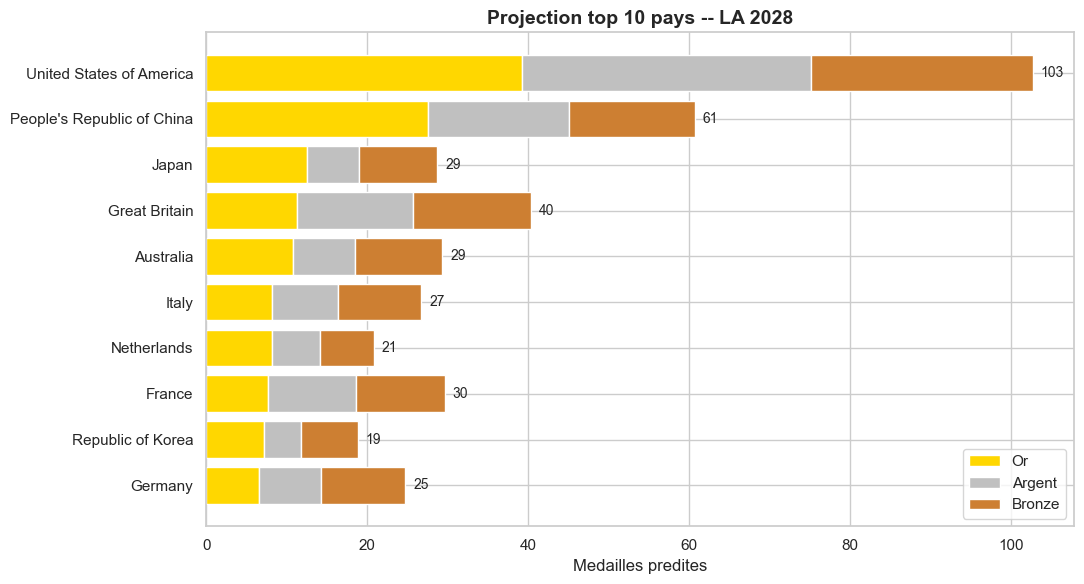

In [9]:
fig, ax = plt.subplots(figsize=(11, 6))
top10 = projection_2028.head(10).iloc[::-1]
ax.barh(top10['Country'], top10['Gold_2028'], color='#FFD700', label='Or')
ax.barh(top10['Country'], top10['Silver_2028'], left=top10['Gold_2028'], color='#C0C0C0', label='Argent')
ax.barh(top10['Country'], top10['Bronze_2028'], left=top10['Gold_2028']+top10['Silver_2028'],
         color='#CD7F32', label='Bronze')
for i, (_, row) in enumerate(top10.iterrows()):
    ax.text(row['Total_2028'] + 1, i, f"{row['Total_2028']:.0f}", va='center', fontsize=10)
ax.set_xlabel('Medailles predites')
ax.set_title('Projection top 10 pays -- LA 2028', fontweight='bold', fontsize=14)
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'projection_top10_2028.png'), bbox_inches='tight', dpi=110)
plt.show()

## Conclusion

3 modeles Ridge simples, classement final disponible dans `data/processed/projection_2028_country.csv`.